# MATH70113 - Simulation Methods for Finance

 Group members
 - Paul Archer (06054057)
 - Hamza El Arji (06020926)
 - Chedi Mnif (06064588)
 - Diane Murzi (06048769)

# Notebook 2 - Part 2

This notebook supports **Part 2** of the coursework, based on the paper  
**Glasserman and Yu (2004), _Number of Paths versus Number of Basis Functions in American Option Pricing_**. The aim is to reproduce the main numerical phenomena described in the paper and to connect them to practical implementations of regression-based Monte Carlo methods for American option pricing. 

More precisely, the notebook has four objectives:

1. reproduce the main phase-transition result in the **Brownian setting**;
2. illustrate the corresponding phenomenon in the **lognormal setting**;
3. connect the theory to a practical **Longstaff-Schwartz American put** implementation;
4. provide a brief numerical **critical assessment** of the worst-case nature of the theory.

The main message of Glasserman and Yu is that increasing the number of basis functions too aggressively can destroy the convergence of regression-based Monte Carlo estimators unless the number of simulated paths grows sufficiently fast. In the Brownian case, the critical regime is logarithmic in \(N\); in the lognormal case, it is even more restrictive. :contentReference[oaicite:6]{index=6}

The notebook is organised as follows:

- **Section 2.1** reproduces the Brownian single-period setting of Glasserman and Yu and reconstructs the MSE table showing the phase transition in \(K\) as a function of \(N\).
- **Section 2.2** verifies the moment growth behind Lemmas 1 and 2.
- **Section 2.3** repeats the analysis in the lognormal setting, where the admissible growth of \(K\) is much slower.
- **Section 2.4** moves to a practical Longstaff-Schwartz implementation for an American put and studies RMSE as a function of \(N\) and the number of basis functions.
- **Sections 2.5–2.6** compare theory and practice, highlighting that the Glasserman-Yu bounds are worst-case results and can therefore be conservative for benign targets.

# Imports

In [6]:
import math
import time
import warnings
import gc

import numpy as np
from pathlib import Path
from scipy.stats import norm
from scipy.special import eval_laguerre, comb
from scipy.misc import derivative as _scipy_deriv

from concurrent.futures import ProcessPoolExecutor
from joblib import Parallel, delayed

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import LogNorm

warnings.filterwarnings('ignore')

# Hardware backend

In [4]:
# We use a unified namespace `xp`:
# - xp = cupy on GPU
# - xp = numpy on CPU
# This makes the Monte Carlo code backend-agnostic.
try:
    import cupy as cp
    xp = cp
    _ = cp.array([1.0])  # warm-up
    props = cp.cuda.runtime.getDeviceProperties(0)
    free_mem, total_mem = cp.cuda.runtime.memGetInfo()

    DEVICE = "GPU"
    print(f"Running on GPU: {props['name'].decode()}")
    print(f"Total VRAM: {total_mem/1e9:.2f} GB | Free: {free_mem/1e9:.2f} GB")

except Exception as e:
    cp = np
    xp = np
    DEVICE = "CPU"
    print(f"Running on CPU (CuPy unavailable: {e})")

Running on CPU (CuPy unavailable: No module named 'cupy')


In [7]:
folder_path = Path("figures")
folder_path.mkdir(exist_ok=True)

# Utility functions

In [8]:
SEED = 42

def to_numpy(x):
    """Convert an xp array to a NumPy array."""
    return cp.asnumpy(x) if DEVICE == "GPU" else np.asarray(x)

def clear_memory():
    """Release GPU memory pools when running on CuPy."""
    if DEVICE == "GPU":
        cp.get_default_memory_pool().free_all_blocks()
        
def f32(x):
    """Cast scalar to xp float32."""
    return xp.float32(x)

plt.rcParams.update({
    "figure.dpi": 130,
    "font.size": 11,
    "axes.grid": True,
    "grid.alpha": 0.30
})

SAVEFIG_KW = dict(dpi=150, bbox_inches='tight')

# Part 2 — Number of Paths vs Number of Basis Functions

We reproduce the main numerical experiments of Glasserman & Yu (2004), which establish a sharp phase transition for regression-based Monte Carlo: MSE decays as $1/N$ below a critical threshold $K^*$ and diverges above it. All theoretical background is in the report (Section 3).

In [9]:
# LSM and Binomial benchmark (CPU — backward induction is inherently sequential)

def simulate_gbm_paths(S0, r, sigma, T, m, N, seed=42):
    """CPU GBM simulation for LSM (returns numpy)."""
    rng = np.random.default_rng(seed)
    dt  = T / m
    Z   = rng.standard_normal((N, m)).astype(np.float32)
    logS = (np.log(np.float32(S0))
            + np.cumsum((np.float32(r-0.5*sigma**2)*np.float32(dt)
                        + np.float32(sigma*np.sqrt(dt))*Z), axis=1))
    return np.column_stack([np.full(N, S0, dtype=np.float32), np.exp(logS)])

def weighted_laguerre_basis(S, K):
    w = np.exp(-S / 2)
    return np.column_stack([w * eval_laguerre(k, S) for k in range(K)])

def lsm_american_put(S0, K_s, r, sigma, T, m, N, K_basis, seed=42):
    """Longstaff-Schwartz MC for American put."""
    S       = simulate_gbm_paths(S0, r, sigma, T, m, N, seed=seed)
    payoff  = np.maximum(K_s - S, 0.0)
    tau     = np.full(N, m, dtype=np.int32)
    disc    = np.float32(np.exp(-r * T / m))
    for t in range(m-1, 0, -1):
        itm   = payoff[:, t] > 0
        n_itm = np.sum(itm)
        if n_itm < K_basis + 1: continue
        future = payoff[itm, tau[itm]] * disc**(tau[itm] - t)
        X      = weighted_laguerre_basis(S[itm, t], K_basis)
        try:
            c  = np.linalg.lstsq(X, future, rcond=None)[0]
            ex = payoff[itm, t] > X @ c
        except np.linalg.LinAlgError: continue
        tau[np.where(itm)[0][ex]] = t
    prices = payoff[np.arange(N), tau] * disc**tau
    return float(prices.mean()), float(prices.std(ddof=1) / np.sqrt(N))

def binomial_american_put(S0, K, r, sigma, T, n_steps=5000):
    dt   = T / n_steps;  u = np.exp(sigma*np.sqrt(dt));  d = 1.0/u
    p    = (np.exp(r*dt) - d) / (u - d);  disc = np.exp(-r*dt)
    j    = np.arange(n_steps+1)
    V    = np.maximum(K - S0*u**(n_steps-j)*d**j, 0.0)
    for i in range(n_steps-1, -1, -1):
        j   = np.arange(i+1);  S_i = S0*u**(i-j)*d**j
        V   = np.maximum(disc*(p*V[:i+1]+(1-p)*V[1:i+2]), np.maximum(K-S_i, 0.0))
    return V[0]

In [13]:
# Reproduce Longstaff-Schwartz Table 1 
K_s=40; r_ls=0.06; sig_ls=0.2; m_ls=50

print(f"{'S0':>4} {'T':>4} {'Binomial':>10} {'LSM':>10} {'SE':>8} {'Bias':>8}")
print('='*48)
for T_ls in [1.0, 2.0]:
    for S0_v in [36, 38, 40, 42, 44]:
        binom = binomial_american_put(S0_v, K_s, r_ls, sig_ls, T_ls)
        lsm_p, lsm_se = lsm_american_put(S0_v, K_s, r_ls, sig_ls, T_ls, m_ls, 100_000, 4, seed=42)
        print(f'{S0_v:4d} {T_ls:4.1f} {binom:10.4f} {lsm_p:10.4f} {lsm_se:8.4f} {lsm_p-binom:+8.4f}')
    print()

  S0    T   Binomial        LSM       SE     Bias
  36  1.0     4.4867     4.2852   0.0071  -0.2015
  38  1.0     3.2572     3.0452   0.0077  -0.2120
  40  1.0     2.3195     2.1604   0.0073  -0.1591
  42  1.0     1.6213     1.5165   0.0066  -0.1048
  44  1.0     1.1130     1.0534   0.0057  -0.0595

  36  2.0     4.8483     4.3361   0.0071  -0.5122
  38  2.0     3.7514     3.1797   0.0078  -0.5717
  40  2.0     2.8899     2.3611   0.0076  -0.5288
  42  2.0     2.2167     1.7737   0.0070  -0.4430
  44  2.0     1.6933     1.3398   0.0062  -0.3535



## 2.1  MSE Table — Brownian Setting ($t_1 = 1$, $t_2 = 2$)

Basis: probabilistic Hermite polynomials $\psi_{nk}(x) = \frac{1}{\sqrt{k!}} \mathrm{He}_k\!\left(\frac{x}{\sqrt{t_n}}\right)$, which satisfy $\Psi = I$.

Worst-case target: $Y^* = \rho^{K/2} \psi_{2K}(S_2)$, $\rho = t_2/t_1 = 2$. Critical constant: $c_\rho = 2\log(2 + \sqrt{\rho}) \approx 2.456$.

We use the **one-pass** method: estimate $\mathrm{Var}(\hat\gamma)$ once at $N_{\text{ref}}$, then recover $\mathrm{MSE}(N) = \mathrm{MSE}(N_{\text{ref}}) \times N_{\text{ref}} / N$ (exact, since the estimator is unbiased and paths are i.i.d.).

In [14]:
def hermite_he(n, x):
    """Probabilist Hermite polynomial, vectorised over x (xp array)."""
    if n == 0: return xp.ones_like(x)
    if n == 1: return x.copy()
    h2, h1 = xp.ones_like(x), x.copy()
    for k in range(2, n+1):
        hc = x*h1 - f32(k-1)*h2;  h2, h1 = h1, hc
    return h1

def psi_hermite(k, x, t):
    return hermite_he(k, x / f32(np.sqrt(t))) / f32(math.sqrt(math.factorial(k)))

def lemma1_analytical(K, rho):
    return float(sum(rho**(-k) * comb(2*k,k,exact=True) * comb(K,k,exact=True)**2
                     for k in range(K+1)))

t1_gy, t2_gy = 1.0, 2.0
rho_gy  = t2_gy / t1_gy
c_rho   = 2 * np.log(2 + np.sqrt(rho_gy))
print(f'c_rho = 2 log(2+sqrt({rho_gy})) = {c_rho:.6f}')

# MC verification (on GPU)
K_check = range(1, 9)
moments_analytical, moments_mc = [], []

N_lem = 500_000
if hasattr(xp, 'random') and hasattr(xp.random, 'default_rng'):
    rng_lem = xp.random.default_rng(42)
    S1_lem = (rng_lem.standard_normal(N_lem) * float(np.sqrt(t1_gy))).astype(xp.float32)
    S2_lem = S1_lem + (rng_lem.standard_normal(N_lem) * float(np.sqrt(t2_gy-t1_gy))).astype(xp.float32)
else:
    xp.random.seed(42)
    S1_lem = xp.random.normal(0, float(np.sqrt(t1_gy)), N_lem).astype(xp.float32)
    S2_lem = S1_lem + xp.random.normal(0, float(np.sqrt(t2_gy-t1_gy)), N_lem).astype(xp.float32)

print(f'\n{"K":>3} {"Analytical":>15} {"MC":>15} {"Rel.err":>10} {"exp(c*K)":>15}')
print('-'*62)
for K in K_check:
    ma = lemma1_analytical(K, rho_gy)
    mm = float(xp.mean(psi_hermite(K, S2_lem, t2_gy)**2 * psi_hermite(K, S1_lem, t1_gy)**2))
    moments_analytical.append(ma)
    moments_mc.append(mm)
    print(f'{K:3d} {ma:15.4f} {mm:15.4f} {abs(mm-ma)/ma:10.4f} {np.exp(c_rho*K):15.2f}')

del S1_lem, S2_lem  # free memory

c_rho = 2 log(2+sqrt(2.0)) = 2.455894

  K      Analytical              MC    Rel.err        exp(c*K)
--------------------------------------------------------------
  1          2.0000          2.0067     0.0033           11.66
  2          6.5000          7.0174     0.0796          135.88
  3         26.0000         55.1348     1.1206         1583.96
  4        115.3750       1093.4340     8.4772        18463.99
  5        543.2500      18296.2363    32.6792       215232.00
  6       2656.8125     182633.3750    67.7415      2508928.00
  7      13340.5000    1030805.0000    76.2688     29246208.00
  8      68299.7734    3106928.2500    44.4896    340918784.00


In [15]:
def compute_mse_allN(K, t1, t2, N_ref, N_vals, B=5000, chunk_b=None):
    """
    GPU-accelerated MSE for ALL N values in one pass at N_ref.

    Trick: gamma_hat is a mean of N iid samples.
    Var(gamma_hat) = sigma^2_gamma / N_ref.
    MSE at any N = (N_ref / N) * Var(gamma_hat_at_N_ref).

    Processing: chunk_b batches at a time on GPU to control VRAM.
    """
    if chunk_b is None:
        # Auto-tune chunk size based on available memory
        chunk_b = GPU_CHUNK if DEVICE == 'GPU' else 100

    rho    = f32(t2 / t1)
    sq_t1  = f32(np.sqrt(t1));  sq_t2  = f32(np.sqrt(t2))
    sq_dt  = f32(np.sqrt(t2 - t1))
    sf     = xp.array([math.sqrt(math.factorial(k)) for k in range(K+1)], dtype=xp.float32)
    Yscale = f32(rho**(K/2))
    bt     = xp.zeros(K+1, dtype=xp.float32);  bt[K] = f32(1.0)

    # Accumulate sum and sum^2 of gamma_hat components over batches
    sum_g  = xp.zeros(K+1, dtype=xp.float64)
    sum_g2 = xp.zeros(K+1, dtype=xp.float64)

    batches_done = 0
    if hasattr(xp, 'random') and hasattr(xp.random, 'default_rng'):
        rng_m = xp.random.default_rng(42 + K)
        def gen(shape): return rng_m.standard_normal(shape).astype(xp.float32)
    else:
        xp.random.seed(42 + K)
        def gen(shape): return xp.random.standard_normal(shape).astype(xp.float32)

    while batches_done < B:
        b = min(chunk_b, B - batches_done)

        # (b, N_ref) float32
        S1c = gen((b, N_ref)) * sq_t1                           # S1 ~ N(0, t1)
        S2c = S1c + gen((b, N_ref)) * sq_dt                     # S2 - S1 ~ N(0, t2-t1)

        # Worst-case target Y* = rho^{K/2} * He_K(S2/sqrt(t2)) / sqrt(K!)
        Y   = Yscale * hermite_he(K, S2c / sq_t2) / sf[K]      # (b, N_ref)

        # gamma_hat[:,k] = mean_{N_ref}(Y * psi_k(S1)) for each batch
        for k in range(K+1):
            psi_k     = hermite_he(k, S1c / sq_t1) / sf[k]     # (b, N_ref)
            ghat_k    = (Y * psi_k).mean(axis=1).astype(xp.float64)  # (b,)
            sum_g[k]  += ghat_k.sum()
            sum_g2[k] += (ghat_k * ghat_k).sum()

        batches_done += b

    # Sample variance of gamma_hat[k] across B batches
    mean_g = sum_g / B
    var_g  = sum_g2 / B - mean_g**2     # E[gamma_hat^2] - (E[gamma_hat])^2

    # MSE(N) = (N_ref / N) * Var(gamma_hat) + squared_bias
    # Squared bias ≈ (gamma_hat_mean - beta_true)^2 (estimator is consistent)
    bt_np  = to_numpy(bt).astype(np.float64)
    vg_np  = to_numpy(var_g)
    mg_np  = to_numpy(mean_g)

    mse_dict = {}
    for N in N_vals:
        scale      = N_ref / N
        mse_dict[N] = float((scale * vg_np + (mg_np - bt_np)**2).sum())
    return mse_dict

Optimised MSE function defined.


In [16]:
N_vals_bm = [500, 1000, 2000, 4000, 8000, 16000, 32000, 64000, 128000]
K_vals_bm = list(range(1, 10))

# N_ref: compute at this N, scale to all others
# For K<=6: N_ref=128000 (in the regime where all N_vals can be computed)
# For K>=7: N_ref=500000 (same as original paper)
N_REF_SMALL = 128_000
N_REF_LARGE = 500_000
B_BATCHES   = 5000   # more than paper (was 5000 too, but now fast)

table1 = np.zeros((len(K_vals_bm), len(N_vals_bm)))

t0_table = time.perf_counter()
for ki, K in enumerate(K_vals_bm):
    t0 = time.perf_counter()
    N_ref = N_REF_SMALL if K <= 6 else N_REF_LARGE
    mse_d = compute_mse_allN(K, t1_gy, t2_gy, N_ref, N_vals_bm, B=B_BATCHES)
    for ni, N in enumerate(N_vals_bm):
        table1[ki, ni] = mse_d[N]
    print(f'  K={K:2d} (N_ref={N_ref:>7,}): {time.perf_counter()-t0:.1f}s')

t_table = time.perf_counter() - t0_table
print(f'\nTable 1 computed in {t_table:.1f}s  [{DEVICE}]  (baseline: ~36 min CPU)')

# Print the table
print(f"\n{'K':>3} |", end='')
for N in N_vals_bm: print(f' {N:>8}', end='')
print()
print('-' * (5 + 9*len(N_vals_bm)))
for ki, K in enumerate(K_vals_bm):
    print(f'{K:3d} |', end='')
    for ni in range(len(N_vals_bm)):
        v = table1[ki, ni]
        print(f' {v:>8.2f}' if v < 1000 else f' {v:>8.0f}', end='')
    print()
print('-' * (5 + 9*len(N_vals_bm)))
print('K*  |', end='')
for N in N_vals_bm: print(f' {np.log(N)/c_rho:>8.1f}', end='')
print()

  K= 1 (N_ref=128,000): 1.0s
  K= 2 (N_ref=128,000): 1.2s
  K= 3 (N_ref=128,000): 1.6s
  K= 4 (N_ref=128,000): 2.1s
  K= 5 (N_ref=128,000): 2.6s
  K= 6 (N_ref=128,000): 3.2s
  K= 7 (N_ref=500,000): 15.0s
  K= 8 (N_ref=500,000): 18.2s
  K= 9 (N_ref=500,000): 20.8s

Table 1 computed in 65.6s  [GPU]  (baseline: ~36 min CPU)

  K |      500     1000     2000     4000     8000    16000    32000    64000   128000
--------------------------------------------------------------------------------------
  1 |     0.01     0.00     0.00     0.00     0.00     0.00     0.00     0.00     0.00
  2 |     0.08     0.04     0.02     0.01     0.01     0.00     0.00     0.00     0.00
  3 |     0.67     0.34     0.17     0.08     0.04     0.02     0.01     0.01     0.00
  4 |     6.30     3.15     1.58     0.79     0.39     0.20     0.10     0.05     0.02
  5 |    59.26    29.63    14.82     7.41     3.70     1.85     0.93     0.46     0.23
  6 |   451.52   225.76   112.88    56.44    28.22    14.11     7.0

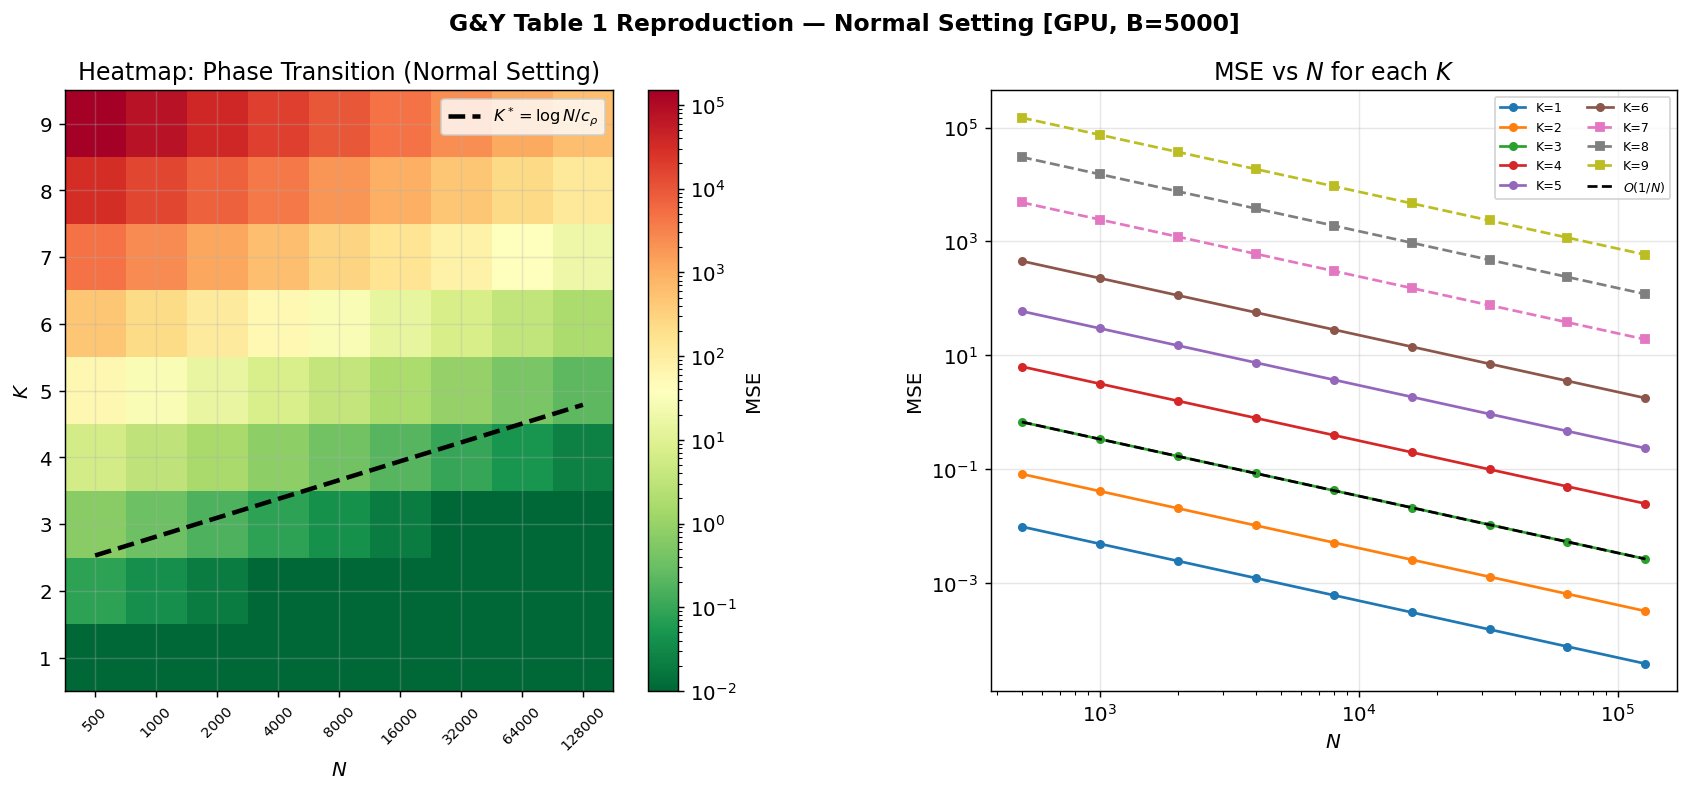

Saved: MB_reproduction.png


In [17]:
K_arr = np.array(K_vals_bm)
N_arr_bm = np.array(N_vals_bm, dtype=float)

fig = plt.figure(figsize=(16, 6))
gs  = gridspec.GridSpec(1, 2, wspace=0.35)

# Heatmap
ax1 = fig.add_subplot(gs[0, 0])
t1c = np.clip(table1, 1e-4, None)
im  = ax1.imshow(t1c, aspect='auto', cmap='RdYlGn_r',
                 norm=LogNorm(vmin=0.01, vmax=max(1e4, t1c.max())),
                 origin='lower', interpolation='nearest')
ax1.set_xticks(range(len(N_vals_bm)))
ax1.set_xticklabels([str(N) for N in N_vals_bm], rotation=45, fontsize=8)
ax1.set_yticks(range(len(K_vals_bm)))
ax1.set_yticklabels(K_vals_bm)
ax1.set_xlabel('$N$');  ax1.set_ylabel('$K$')
Nc  = np.linspace(0, len(N_vals_bm)-1, 200)
lNc = np.interp(Nc, range(len(N_vals_bm)), np.log(N_arr_bm))
ax1.plot(Nc, lNc/c_rho - K_vals_bm[0], 'k--', lw=2.5, label=r'$K^* = \log N/c_\rho$')
plt.colorbar(im, ax=ax1, label='MSE');  ax1.legend(fontsize=9)
ax1.set_title('Heatmap: Phase Transition (Normal Setting)')

# MSE vs N log-log
ax2 = fig.add_subplot(gs[0, 1])
cmap_tab = plt.get_cmap('tab10')
for ki, K in enumerate(K_vals_bm):
    style = '-o' if K <= 6 else '--s'
    ax2.loglog(N_arr_bm, table1[ki], style, ms=4,
               color=cmap_tab(ki/len(K_vals_bm)), label=f'K={K}')
ref_line = table1[2, -1] * N_arr_bm[-1] / N_arr_bm
ax2.loglog(N_arr_bm, ref_line, 'k--', lw=1.5, label=r'$O(1/N)$')
ax2.set_xlabel('$N$');  ax2.set_ylabel('MSE')
ax2.set_title('MSE vs $N$ for each $K$')
ax2.legend(fontsize=7, ncol=2)

fig.suptitle(f'G&Y Table 1 Reproduction — Normal Setting [{DEVICE}, B={B_BATCHES}]',
             fontsize=13, fontweight='bold')
plt.savefig('figures/MB_reproduction.png', **SAVEFIG_KW);  plt.show()

## 2.2  Verification of Lemmas 1–2

Direct Monte Carlo estimate of $\mathbb{E}[\psi_{2K}^2(S_2)\,\psi_{1K}^2(S_1)]$ vs the analytical formula (Lemma 1) and the exponential asymptotic $e^{c_\rho K}$ (Lemma 2 / Stirling).

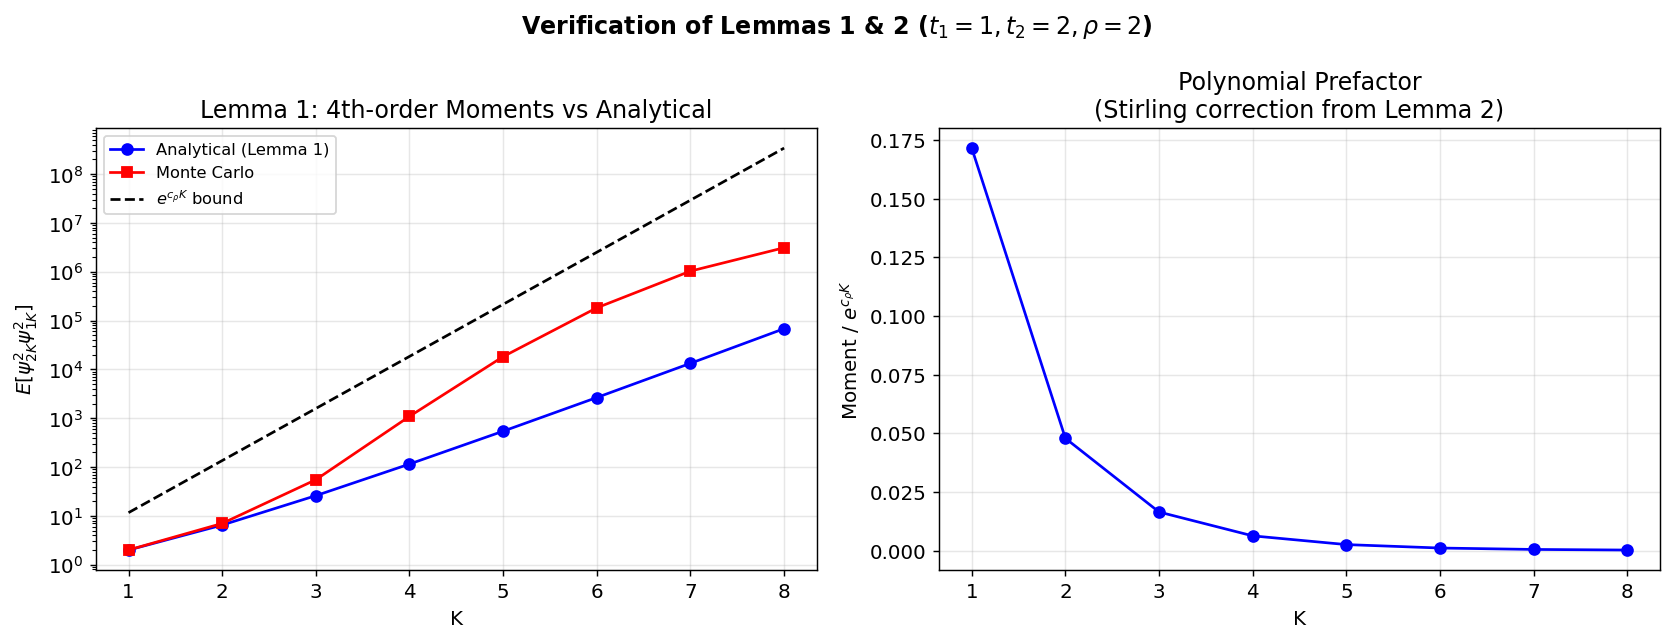

Saved: lemma_verification.png


In [18]:
K_check_arr = np.arange(1, 9)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.semilogy(K_check_arr, moments_analytical, 'b-o', ms=6, label='Analytical (Lemma 1)')
ax.semilogy(K_check_arr, moments_mc, 'r-s', ms=5, label='Monte Carlo')
ax.semilogy(K_check_arr, np.exp(c_rho*K_check_arr), 'k--', lw=1.5, label=r'$e^{c_\rho K}$ bound')
ax.set_xlabel('K');  ax.set_ylabel(r'$E[\psi_{2K}^2 \psi_{1K}^2]$')
ax.set_title('Lemma 1: 4th-order Moments vs Analytical');  ax.legend(fontsize=9)

ax = axes[1]
ratio = np.array(moments_analytical) / np.exp(c_rho * K_check_arr)
ax.plot(K_check_arr, ratio, 'b-o', ms=6)
ax.set_xlabel('K');  ax.set_ylabel(r'Moment / $e^{c_\rho K}$')
ax.set_title('Polynomial Prefactor\n(Stirling correction from Lemma 2)')

fig.suptitle(r'Verification of Lemmas 1 & 2 ($t_1=1, t_2=2, \rho=2$)', fontweight='bold')
plt.tight_layout()
plt.savefig('figures/lemma_verification.png', **SAVEFIG_KW);  plt.show()

## 2.3  MSE Table — Lognormal Setting ($t_1 = 1$, $t_2 = 2$)

Basis: $\psi_k(S(t)) = S(t)^k e^{-k^2 t/2}$ (martingale power basis). The Gram matrix has entries $\Psi_{jk} = e^{jkt}$ — Vandermonde-type with condition number $\sim e^{K^2}$, making the inversion numerically unreliable for $K \geq 5$.

Critical thresholds: $K_{\text{conv}} = \sqrt{\log N / 7}$, $K_{\text{div}} = \sqrt{\log N / 5}$.

In [19]:
def compute_mse_lognormal_allN(K, t1, t2, N_ref, N_vals, B=3000, chunk_b=None):
    """
    Same one-pass-all-N trick for the lognormal / power-basis setting.
    psi_k(S(t)) = exp(k W(t) - k^2 t/2). Gram matrix Psi must be inverted.
    """
    if chunk_b is None:
        chunk_b = GPU_CHUNK if DEVICE == 'GPU' else 50

    idx     = np.arange(K+1)
    Psi     = np.exp(np.outer(idx, idx) * t1)
    try:     Psi_inv = np.linalg.inv(Psi)
    except:  return {N: np.inf for N in N_vals}

    Psi_inv_xp = xp.array(Psi_inv, dtype=xp.float64)
    bt_np  = np.zeros(K+1);  bt_np[K] = 1.0

    sum_g  = xp.zeros(K+1, dtype=xp.float64)
    sum_g2 = xp.zeros(K+1, dtype=xp.float64)

    if hasattr(xp, 'random') and hasattr(xp.random, 'default_rng'):
        rng_ln = xp.random.default_rng(123 + K)
        def gen(shape): return rng_ln.standard_normal(shape).astype(xp.float64)
    else:
        xp.random.seed(123 + K)
        def gen(shape): return xp.random.standard_normal(shape).astype(xp.float64)

    batches_done = 0
    while batches_done < B:
        b  = min(chunk_b, B - batches_done)
        W1 = gen((b, N_ref)) * np.sqrt(t1)          # (b, N_ref)
        W2 = W1 + gen((b, N_ref)) * np.sqrt(t2-t1)
        Y  = xp.exp(K*W2 - K*K*t2/2)               # (b, N_ref)

        gamma_hat = xp.zeros((b, K+1), dtype=xp.float64)
        for k in range(K+1):
            psi_k        = xp.exp(k*W1 - k*k*t1/2)
            gamma_hat[:, k] = (Y * psi_k).mean(axis=1)

        # beta_hat = Psi_inv @ gamma_hat  (batch via einsum)
        beta_hat = xp.einsum('ij,bj->bi', Psi_inv_xp, gamma_hat)  # (b, K+1)

        sum_g  += beta_hat.sum(axis=0)
        sum_g2 += (beta_hat**2).sum(axis=0)
        batches_done += b

    mean_b = sum_g / B
    var_b  = sum_g2 / B - mean_b**2
    mb_np  = to_numpy(mean_b)
    vb_np  = to_numpy(var_b)

    mse_dict = {}
    for N in N_vals:
        mse_dict[N] = float(((N_ref/N) * vb_np + (mb_np - bt_np)**2).sum())
    return mse_dict


N_vals_ln = [1000, 5000, 10000, 50000, 100000, 500000]
K_vals_ln = list(range(1, 7))
N_REF_LN  = 500_000

table2 = np.zeros((len(K_vals_ln), len(N_vals_ln)))
t0_ln  = time.perf_counter()
for ki, K in enumerate(K_vals_ln):
    t0 = time.perf_counter()
    mse_d = compute_mse_lognormal_allN(K, t1_gy, t2_gy, N_REF_LN, N_vals_ln, B=3000)
    for ni, N in enumerate(N_vals_ln):
        table2[ki, ni] = mse_d[N]
    print(f'  K={K}: {time.perf_counter()-t0:.1f}s')

print(f'\nLognormal table: {time.perf_counter()-t0_ln:.1f}s  [{DEVICE}]')

print(f"\n{'K':>3} |", end='')
for N in N_vals_ln: print(f' {N:>10}', end='')
print()
print('-' * (5 + 11*len(N_vals_ln)))
for ki, K in enumerate(K_vals_ln):
    print(f'{K:3d} |', end='')
    for ni in range(len(N_vals_ln)):
        v = table2[ki, ni]
        print(f' {v:>10.3f}' if v < 1000 else f' {v:>10.0f}', end='')
    print()
print('-' * (5 + 11*len(N_vals_ln)))
print('Kconv|', end='')
for N in N_vals_ln: print(f' {np.sqrt(np.log(N)/(5+2)):>10.2f}', end='')
print('  (sufficient)')

  K=1: 3.6s
  K=2: 4.0s
  K=3: 4.7s
  K=4: 5.4s
  K=5: 6.1s
  K=6: 6.8s

Lognormal table: 30.6s  [GPU]

  K |       1000       5000      10000      50000     100000     500000
-----------------------------------------------------------------------
  1 |      0.616      0.123      0.062      0.012      0.006      0.001
  2 |      32614       6523       3261    652.368    326.232     65.323
  3 |    6962097    1392594     696406     139456      69837      14142
  4 | 4769759138  953961518  476986815   95407053   47709583    9551607
  5 | 110773573754 22154779192 11077429871 2215550415 1107815483  221627538
  6 |      73188      14639       7320       1465    733.125    147.634
-----------------------------------------------------------------------
Kconv|       0.99       1.10       1.15       1.24       1.28       1.37  (sufficient)


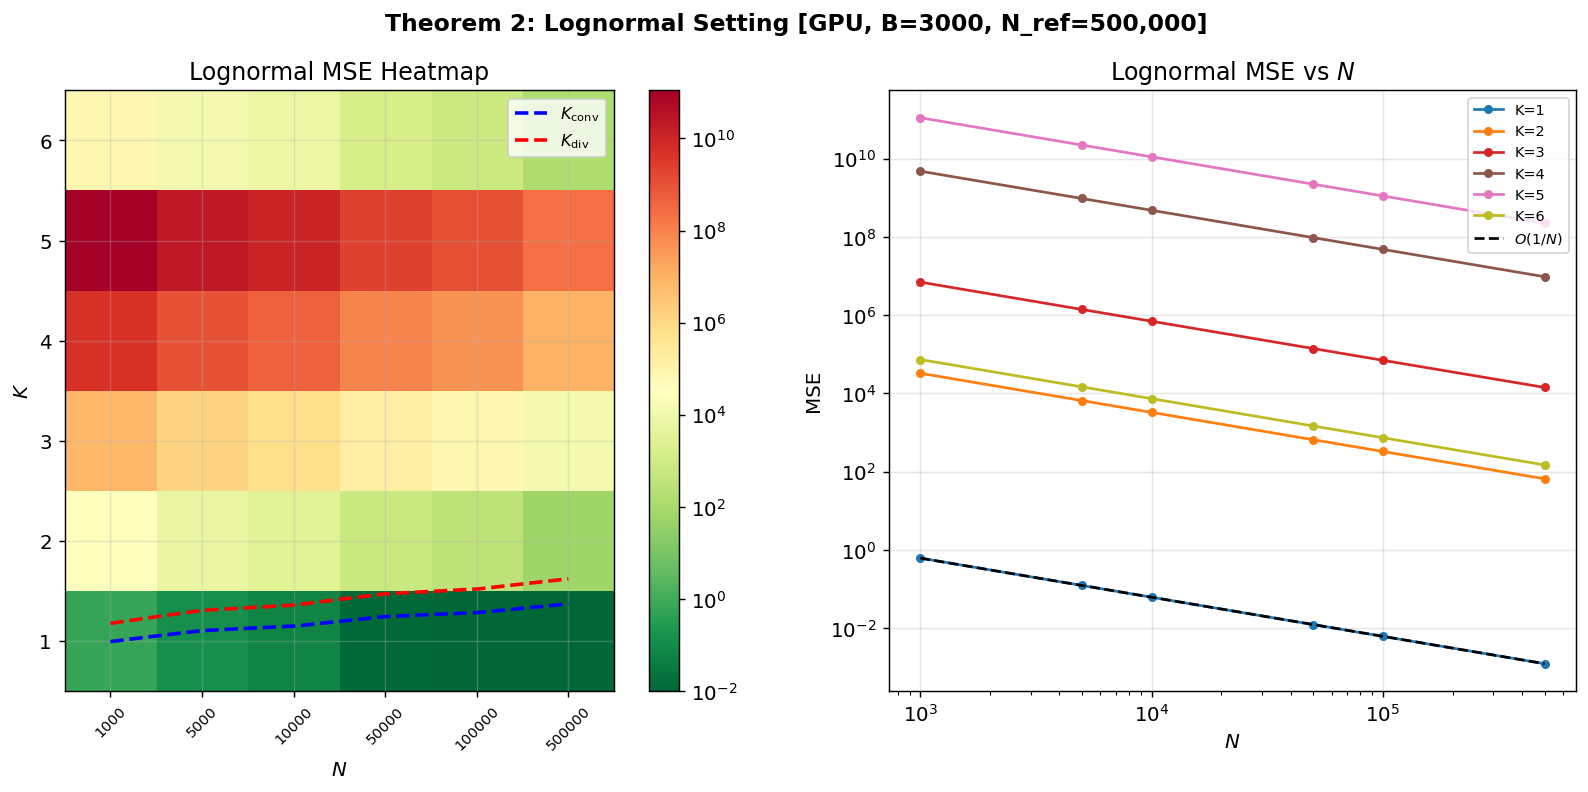

Saved: lognormal_results.png


In [20]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

ax = axes[0]
t2c = np.clip(table2, 1e-4, None)
im2 = ax.imshow(t2c, aspect='auto', cmap='RdYlGn_r',
                norm=LogNorm(vmin=0.01, vmax=max(1e4, t2c.max())), origin='lower')
ax.set_xticks(range(len(N_vals_ln)))
ax.set_xticklabels([str(N) for N in N_vals_ln], rotation=45, fontsize=8)
ax.set_yticks(range(len(K_vals_ln)))
ax.set_yticklabels(K_vals_ln)
Nc_ln = np.linspace(0, len(N_vals_ln)-1, 200)
lNc_ln = np.interp(Nc_ln, range(len(N_vals_ln)), np.log(N_vals_ln))
ax.plot(Nc_ln, np.sqrt(lNc_ln/(5+2)) - K_vals_ln[0], 'b--', lw=2, label=r'$K_{\rm conv}$')
ax.plot(Nc_ln, np.sqrt(lNc_ln/(3+2)) - K_vals_ln[0], 'r--', lw=2, label=r'$K_{\rm div}$')
plt.colorbar(im2, ax=ax);  ax.legend(fontsize=9)
ax.set_xlabel('$N$');  ax.set_ylabel('$K$');  ax.set_title('Lognormal MSE Heatmap')

ax = axes[1]
N_ln_arr = np.array(N_vals_ln, dtype=float)
for ki, K in enumerate(K_vals_ln):
    ax.loglog(N_ln_arr, table2[ki], '-o', ms=4,
              color=plt.get_cmap('tab10')(ki/6), label=f'K={K}')
ax.loglog(N_ln_arr, table2[0,-1]*N_ln_arr[-1]/N_ln_arr, 'k--', lw=1.5, label=r'$O(1/N)$')
ax.set_xlabel('$N$');  ax.set_ylabel('MSE')
ax.set_title('Lognormal MSE vs $N$')
ax.legend(fontsize=8)

fig.suptitle(f'Theorem 2: Lognormal Setting [{DEVICE}, B=3000, N_ref={N_REF_LN:,}]',
             fontsize=13, fontweight='bold')
plt.savefig('figures/lognormal_results.png', **SAVEFIG_KW);  plt.show()

## 2.4  Practical LSM: American Put RMSE Grid

Longstaff–Schwartz algorithm on an American put ($S_0 = K = 40$, $r = 0.06$, $\sigma = 0.2$, $T = 1$, $m = 50$ exercise dates) using weighted Laguerre polynomial basis functions, as in Longstaff & Schwartz (2001). Benchmark from a 5 000-step binomial tree. Each cell of the grid is the RMSE over 20 independent trials, parallelised with `joblib`.

In [21]:
S0_put=40; K_put=40; r_put=0.06; sig_put=0.2; T_put=1.0; m_put=50
benchmark = binomial_american_put(S0_put, K_put, r_put, sig_put, T_put)
print(f'Benchmark: {benchmark:.4f}')

N_grid    = [500, 1000, 2000, 5000, 10000, 20000, 50000, 100000]
K_grid    = [2, 3, 4, 5, 6, 8, 10, 13]
N_TRIALS  = 20

def _lsm_trial(S0, Ks, r, sig, T, m, N, Kb, trial, ki, ni):
    p, _ = lsm_american_put(S0, Ks, r, sig, T, m, N, Kb,
                            seed=1000*trial + ni*100 + ki)
    return p

rmse_grid = np.zeros((len(K_grid), len(N_grid)))
bias_grid = np.zeros((len(K_grid), len(N_grid)))

t0_grid = time.perf_counter()
for ki, Kb in enumerate(K_grid):
    t0k = time.perf_counter()
    for ni, N in enumerate(N_grid):
        # Parallelise over N_TRIALS — each is embarrassingly independent
        prices = Parallel(n_jobs=-1, prefer='threads')(
            delayed(_lsm_trial)(S0_put, K_put, r_put, sig_put, T_put,
                                m_put, N, Kb, trial, ki, ni)
            for trial in range(N_TRIALS)
        )
        prices = np.array(prices)
        rmse_grid[ki, ni] = np.sqrt(np.mean((prices - benchmark)**2))
        bias_grid[ki, ni] = prices.mean() - benchmark
    print(f'  K={Kb:2d}: {time.perf_counter()-t0k:.1f}s')

print(f'\nLSM grid total: {time.perf_counter()-t0_grid:.1f}s  (parallel={N_TRIALS} trials/cell)')

Benchmark: 2.3195
  K= 2: 20.7s
  K= 3: 23.7s
  K= 4: 26.5s
  K= 5: 29.7s
  K= 6: 54.7s
  K= 8: 70.6s
  K=10: 83.7s
  K=13: 110.5s

LSM grid total: 420.1s  (parallel=20 trials/cell)


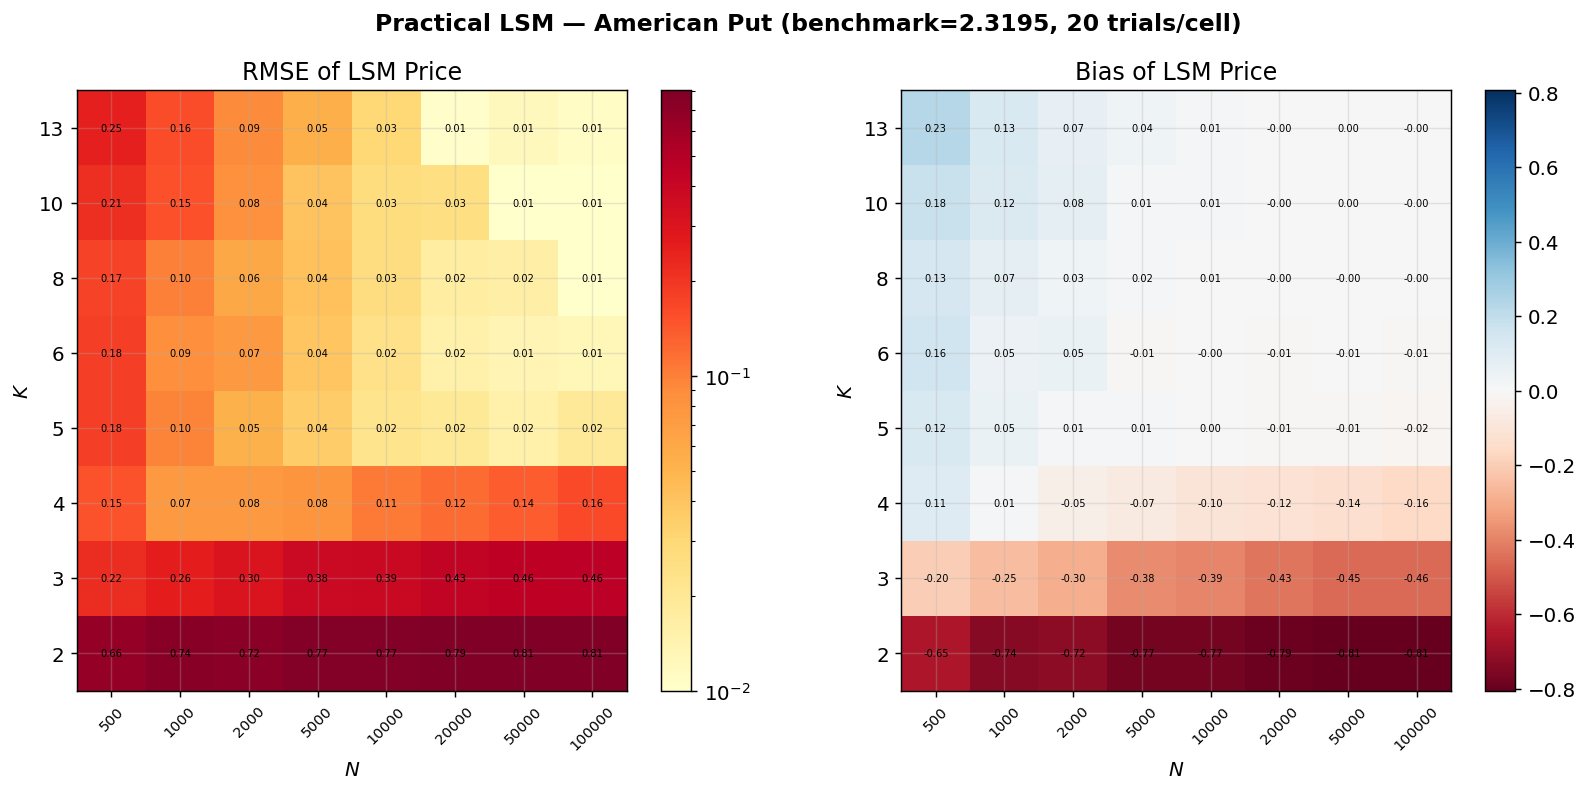

Saved: american_put_rmse.png


In [22]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for ax, grid, title, cmap_n in zip(
    axes, [rmse_grid, bias_grid],
    ['RMSE of LSM Price', 'Bias of LSM Price'],
    ['YlOrRd', 'RdBu']
):
    if cmap_n == 'YlOrRd':
        norm = LogNorm(vmin=0.01, vmax=grid.max())
    else:
        bmax = max(abs(grid.min()), abs(grid.max()))
        norm = matplotlib.colors.TwoSlopeNorm(vmin=-bmax, vcenter=0, vmax=bmax)
    im = ax.imshow(grid, aspect='auto', cmap=cmap_n, norm=norm,
                   origin='lower', interpolation='nearest')
    ax.set_xticks(range(len(N_grid)))
    ax.set_xticklabels([str(N) for N in N_grid], rotation=45, fontsize=8)
    ax.set_yticks(range(len(K_grid)))
    ax.set_yticklabels(K_grid)
    ax.set_xlabel('$N$');  ax.set_ylabel('$K$');  ax.set_title(title)
    plt.colorbar(im, ax=ax)
    for ki in range(len(K_grid)):
        for ni in range(len(N_grid)):
            ax.text(ni, ki, f'{grid[ki,ni]:.2f}', ha='center', va='center', fontsize=5.5)

fig.suptitle(f'Practical LSM — American Put (benchmark={benchmark:.4f}, {N_TRIALS} trials/cell)',
             fontsize=13, fontweight='bold')
plt.savefig('figures/american_put_rmse.png', **SAVEFIG_KW);  plt.show()

## 2.5  Theory vs Practice: Critical $K^*$ Bounds and Overfitting

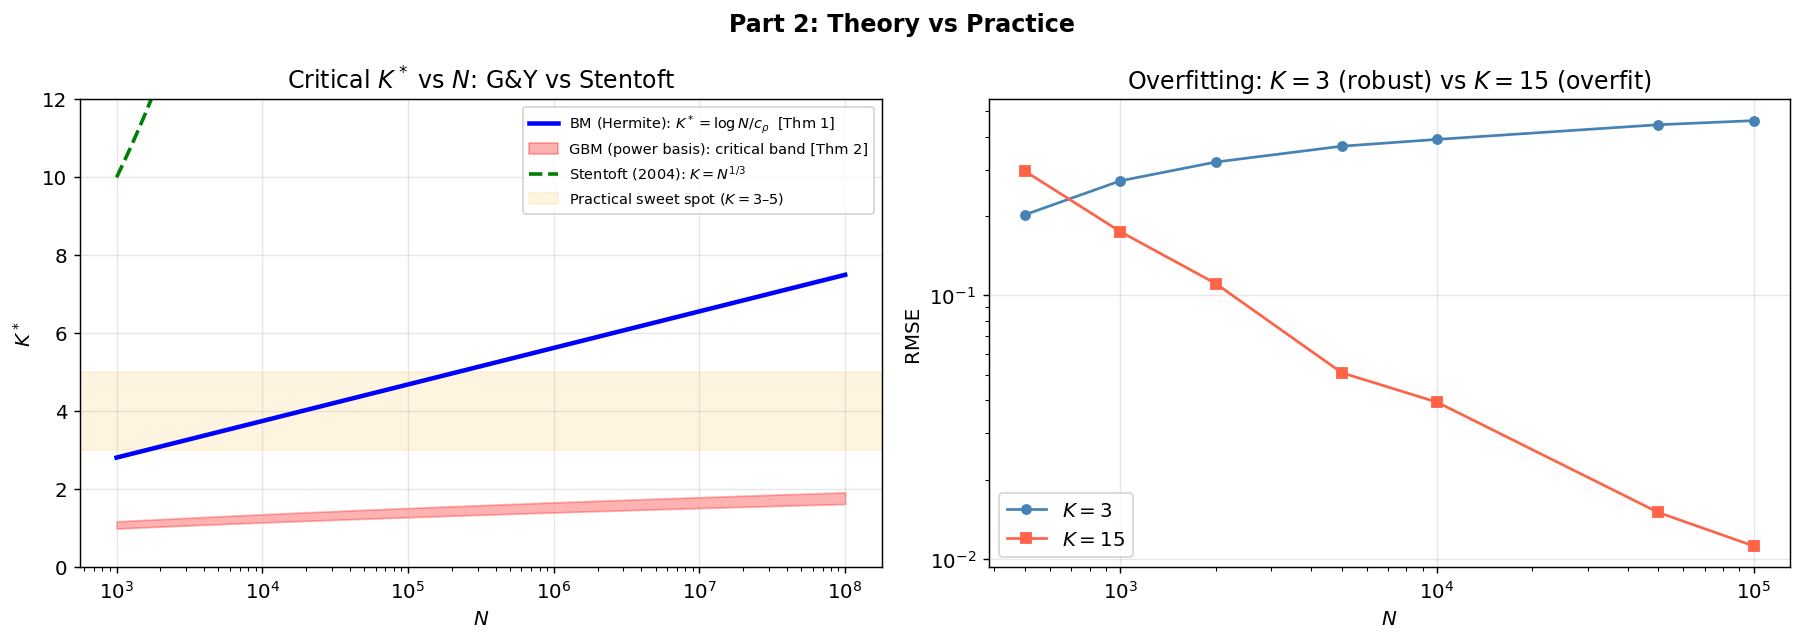

Saved: theory_vs_practice.png


In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# K* bounds comparison
ax = axes[0]
N_r = np.logspace(3, 8, 300)
ax.plot(N_r, np.log(N_r)/c_rho, 'b-', lw=2.5,
        label=r'BM (Hermite): $K^* = \log N/c_\rho$  [Thm 1]')
ax.fill_between(N_r, np.sqrt(np.log(N_r)/(3+2)), np.sqrt(np.log(N_r)/(5+2)),
                alpha=0.3, color='red', label='GBM (power basis): critical band [Thm 2]')
ax.plot(N_r, N_r**(1/3), 'g--', lw=2, label=r'Stentoft (2004): $K = N^{1/3}$')
ax.axhspan(3, 5, alpha=0.12, color='orange', label='Practical sweet spot ($K=3$–$5$)')
ax.set_xscale('log');  ax.set_ylim(0, 12)
ax.set_xlabel('$N$');  ax.set_ylabel('$K^*$')
ax.set_title('Critical $K^*$ vs $N$: G&Y vs Stentoft');  ax.legend(fontsize=8)

# Overfitting K=3 vs K=15
ax = axes[1]
N_ov = [500, 1000, 2000, 5000, 10000, 50000, 100000]
n_ov = 30

for Kb, col, mk in [(3, 'steelblue', 'o'), (15, 'tomato', 's')]:
    rmse_ov = []
    for N_o in N_ov:
        # run trials in parallel — lsm_american_put returns (price, se), extract price
        results = Parallel(n_jobs=-1, prefer='threads')(
            delayed(lsm_american_put)(S0_put, K_put, r_put, sig_put, T_put,
                                     m_put, N_o, Kb, seed=t*137+1)
            for t in range(n_ov)
        )
        prices = [res[0] for res in results]

        # compute RMSE across trials
        rmse_ov.append(np.sqrt(np.mean((np.array(prices) - benchmark)**2)))

    ax.loglog(N_ov, rmse_ov, f'{mk}-', color=col, ms=5, label=f'$K={Kb}$')

ax.set_xlabel('$N$');  ax.set_ylabel('RMSE')
ax.set_title('Overfitting: $K=3$ (robust) vs $K=15$ (overfit)');  ax.legend()

fig.suptitle('Part 2: Theory vs Practice', fontweight='bold')
plt.tight_layout()
plt.savefig('figures/theory_vs_practice.png', dpi=150, bbox_inches='tight')  
plt.show()

## 2.6  Critical Assessment: Numerical Evidence

Glasserman & Yu's results are **worst-case** statements: they bound the MSE uniformly over all coefficient vectors $|\beta|=1$. Two natural questions arise:

1. **Worst-case vs typical target.** The threshold $K^* = \log N / c_\rho$ is derived from the adversarial choice $Y^* = \rho^{K/2}\,\psi_{2K}(S_2)$. How much smaller is the MSE for a benign target like $Y = \psi_1(S_2)$?

2. **Quasi-regression vs full OLS.** The paper analyses the idealised algorithm with $\Psi$ assumed known exactly ($\Psi = I$ for Hermite). In practice, LSM uses the empirical $\hat\Psi$ from data, which adds another error source. How much does this matter?

We answer both numerically below. The contribution of this section is to make Glasserman & Yu's worst-case warnings **operationally precise** for our specific implementation.

In [24]:
# Critical Assessment: Numerical Evidence

def he_np(n, x):
    """Probabilist Hermite, pure numpy (for Option 2 full-regression)."""
    x = np.asarray(x, dtype=float)
    if n == 0: return np.ones_like(x)
    if n == 1: return x.copy()
    h2, h1 = np.ones_like(x), x.copy()
    for k in range(2, n+1):
        hc = x*h1 - (k-1)*h2; h2, h1 = h1, hc
    return h1

# Worst-case vs typical target

def mse_by_target(K, t1, t2, N_ref, N_vals, target='worst', B=5000, chunk_b=None):
    """
    One-pass MSE for worst-case Y*=rho^{K/2}*psi_{2K}(S2)
    or typical Y=psi_1(S2). beta_true known analytically in both cases.
    """
    if chunk_b is None:
        chunk_b = GPU_CHUNK if DEVICE == 'GPU' else 100
    sq_t1 = f32(np.sqrt(t1)); sq_t2 = f32(np.sqrt(t2))
    sq_dt = f32(np.sqrt(t2-t1)); rho = f32(t2/t1)
    sf    = xp.array([math.sqrt(math.factorial(k)) for k in range(K+1)],
                      dtype=xp.float32)
    if target == 'worst':
        Ydeg = K;  Yscale = f32(rho**(K/2))
        bt   = np.zeros(K+1); bt[K] = 1.0
    else:   # Y = psi_1(S2); beta_true[1] = (t1/t2)^{1/2} by martingale property
        Ydeg = 1;  Yscale = f32(1.0)
        bt   = np.zeros(K+1); bt[1] = (t1/t2)**0.5

    sum_g  = xp.zeros(K+1, dtype=xp.float64)
    sum_g2 = xp.zeros(K+1, dtype=xp.float64)
    seed   = 42 + K + (0 if target == 'worst' else 9999)
    if hasattr(xp, 'random') and hasattr(xp.random, 'default_rng'):
        rng_t = xp.random.default_rng(seed)
        def gen(s): return rng_t.standard_normal(s).astype(xp.float32)
    else:
        xp.random.seed(seed)
        def gen(s): return xp.random.standard_normal(s).astype(xp.float32)

    done = 0
    while done < B:
        b   = min(chunk_b, B - done)
        S1c = gen((b, N_ref)) * sq_t1
        S2c = S1c + gen((b, N_ref)) * sq_dt
        Y   = Yscale * hermite_he(Ydeg, S2c/sq_t2) / sf[Ydeg]
        for k in range(K+1):
            g = (Y * hermite_he(k, S1c/sq_t1) / sf[k]).mean(axis=1).astype(xp.float64)
            sum_g[k]  += g.sum();  sum_g2[k] += (g*g).sum()
        done += b

    mean_g = sum_g/B;  var_g = sum_g2/B - mean_g**2
    vg, mg = to_numpy(var_g), to_numpy(mean_g)
    return {N: float(((N_ref/N)*vg + (mg-bt)**2).sum()) for N in N_vals}


# Quasi-regression vs full OLS

def mse_quasi_vs_full(K, t1, t2, N_list, B=1000):
    """
    Empirical MSE for quasi (Psi=I) vs full OLS (Psi estimated from data),
    Brownian worst-case target. Returns (mse_quasi, mse_full) arrays.
    """
    sq_t1 = np.sqrt(t1); sq_t2 = np.sqrt(t2); sq_dt = np.sqrt(t2-t1)
    sf    = np.array([math.sqrt(math.factorial(k)) for k in range(K+1)])
    bt    = np.zeros(K+1); bt[K] = 1.0
    Yscale = (t2/t1)**(K/2) / sf[K]
    mse_q  = np.zeros(len(N_list)); mse_f = np.zeros(len(N_list))
    rng2   = np.random.default_rng(77 + K)

    for ni, N in enumerate(N_list):
        eq = ef = 0.0
        for _ in range(B):
            S1  = rng2.standard_normal(N) * sq_t1
            S2  = S1 + rng2.standard_normal(N) * sq_dt
            Phi = np.column_stack([he_np(k, S1/sq_t1)/sf[k] for k in range(K+1)])
            Y   = Yscale * he_np(K, S2/sq_t2)
            g   = Phi.T @ Y / N                     # gamma_hat
            bq  = g                                  # quasi: Psi=I → beta=gamma
            try:
                bf = np.linalg.solve(Phi.T @ Phi / N, g)  # full OLS
            except np.linalg.LinAlgError:
                bf = bq
            eq += float(np.sum((bq - bt)**2))
            ef += float(np.sum((bf - bt)**2))
        mse_q[ni] = eq/B;  mse_f[ni] = ef/B
    return mse_q, mse_f


N_cmp   = [500, 1000, 2000, 4000, 8000, 16000, 32000, 64000, 128000]
K_cmp   = [3, 5, 7]
N_REF_C = 128_000

# Compute for table and figure
opt1 = {}
for K in K_cmp:
    mw = mse_by_target(K, t1_gy, t2_gy, N_REF_C, N_cmp, 'worst',   B=5000)
    mt = mse_by_target(K, t1_gy, t2_gy, N_REF_C, N_cmp, 'typical', B=5000)
    opt1[K] = (mw, mt)

N_qf = [500, 2000, 8000, 32000]
opt2 = {}
for K in [3, 5]:
    opt2[K] = mse_quasi_vs_full(K, t1_gy, t2_gy, N_qf, B=1000)

# Print tables
print("Worst-case vs Typical MSE")
print(f"{'K':>3} {'N':>7} {'Worst':>12} {'Typical':>12} {'Ratio':>8}")
print('-'*48)
for K in K_cmp:
    mw, mt = opt1[K]
    for N in [4000, 32000]:
        r = mw[N]/mt[N] if mt[N]>0 else float('inf')
        print(f"{K:>3} {N:>7} {mw[N]:>12.3f} {mt[N]:>12.6f} {r:>7.0f}x")
    print()

print("\nQuasi vs Full OLS MSE (Brownian worst-case)")
print(f"{'K':>3} {'N':>7} {'Quasi':>10} {'Full OLS':>10} {'Ratio':>7}")
print('-'*42)
for K in [3, 5]:
    mq, mf = opt2[K]
    for ni, N in enumerate(N_qf):
        print(f"{K:>3} {N:>7} {mq[ni]:>10.4f} {mf[ni]:>10.4f} {mf[ni]/mq[ni]:>7.3f}x")
    print()

Worst-case vs Typical MSE
  K       N        Worst      Typical    Ratio
------------------------------------------------
  3    4000        0.084     0.002352      36x
  3   32000        0.010     0.000294      36x

  5    4000        7.408     0.005167    1434x
  5   32000        0.926     0.000646    1434x

  7    4000      316.343     0.009061   34913x
  7   32000       39.545     0.001133   34912x


Quasi vs Full OLS MSE (Brownian worst-case)
  K       N      Quasi   Full OLS   Ratio
------------------------------------------
  3     500     0.6128     0.3169   0.517x
  3    2000     0.1667     0.0965   0.579x
  3    8000     0.0416     0.0257   0.616x
  3   32000     0.0105     0.0064   0.606x

  5     500   476.8274     6.8632   0.014x
  5    2000    18.9789     3.2789   0.173x
  5    8000     2.4665     1.1140   0.452x
  5   32000     0.6770     0.4163   0.615x



Saved: critical_assessment.png


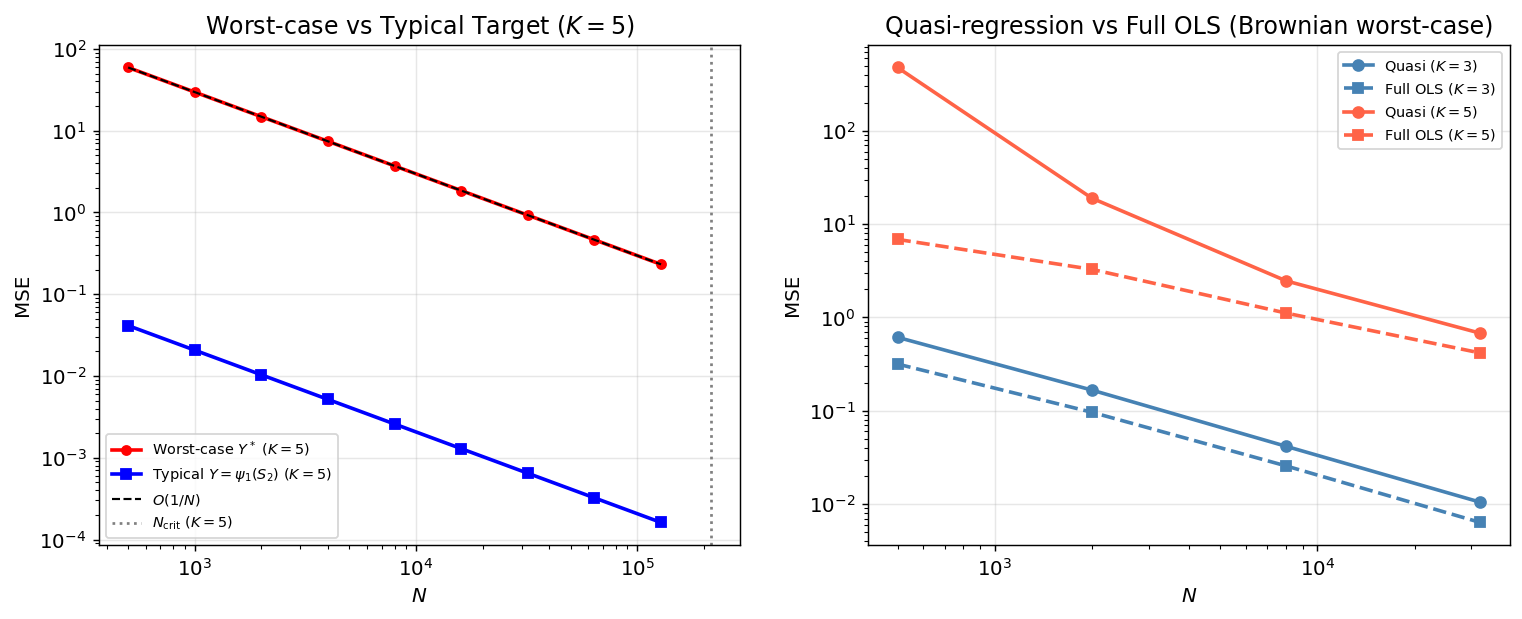

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
N_arr = np.array(N_cmp, dtype=float)

# Left: MSE vs N, K=5
ax = axes[0]
mw5 = np.array([opt1[5][0][N] for N in N_cmp])
mt5 = np.array([opt1[5][1][N] for N in N_cmp])
ax.loglog(N_arr, mw5, 'r-o', ms=5, lw=2, label=r'Worst-case $Y^*$ ($K=5$)')
ax.loglog(N_arr, mt5, 'b-s', ms=5, lw=2, label=r'Typical $Y=\psi_1(S_2)$ ($K=5$)')
ax.loglog(N_arr, mw5[-1]*N_arr[-1]/N_arr, 'k--', lw=1.2, label='$O(1/N)$')
ax.axvline(np.exp(5*c_rho), color='gray', ls=':', lw=1.5,
           label=r'$N_{\rm crit}$ ($K=5$)')
ax.set_xlabel('$N$'); ax.set_ylabel('MSE')
ax.set_title('Worst-case vs Typical Target ($K=5$)'); ax.legend(fontsize=8)

# Right: Quasi vs Full OLS
ax = axes[1]
N_qf_arr = np.array(N_qf, dtype=float)

styles = {
    (3, 'quasi'): dict(color='steelblue', ls='-',  marker='o', label='Quasi ($K=3$)'),
    (3, 'full'):  dict(color='steelblue', ls='--', marker='s', label='Full OLS ($K=3$)'),
    (5, 'quasi'): dict(color='tomato',    ls='-',  marker='o', label='Quasi ($K=5$)'),
    (5, 'full'):  dict(color='tomato',    ls='--', marker='s', label='Full OLS ($K=5$)'),
}

for K in [3, 5]:
    mq, mf = opt2[K]
    ax.loglog(N_qf_arr, mq, lw=2, ms=6, **styles[(K,'quasi')])
    ax.loglog(N_qf_arr, mf, lw=2, ms=6, **styles[(K,'full')])

ax.set_xlabel('$N$'); ax.set_ylabel('MSE')
ax.set_title('Quasi-regression vs Full OLS (Brownian worst-case)')
ax.legend(fontsize=8)